<a href="https://colab.research.google.com/github/healeycm/DSE6230-forecasting-class-course-materials/blob/main/notebooks/week03_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Statistical Methods (ETS and ARIMA)
## In-Class Exercises

**Objective.** Fit the two workhorse statistical families, decide which one a series wants, defend the choice with information criteria *and* out-of-sample error, then hand the same job to an automatic selector and see what it does and does not decide for you.

### How this notebook works

Five parts, each building on the one before it.

| Part | Format | Content |
| --- | --- | --- |
| 1 | Walkthrough | Holt-Winters by hand, additive vs. multiplicative vs. damped, then `AutoETS`. |
| 2 | Blanks we fill in together | Differencing and stationarity: ADF, KPSS, ACF, PACF. |
| 3 | On your own, ~12 min | Pick a SARIMA by hand from the ACF/PACF, beat it with a grid, then race both against `AutoARIMA`. |
| 4 | Walkthrough | Three more series with different shapes, and what the autos pick for each. |
| 5 | Walkthrough + discussion | Timing: what it costs, what drives the cost, and what that means for 1,000 series. |

The notebook runs in two to three minutes, most of it Parts 3 to 5 waiting on ARIMA.


In [49]:
!pip install -q pandas numpy plotly matplotlib statsmodels statsforecast


In [51]:
import time
import warnings
from contextlib import contextmanager

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, SeasonalNaive
from statsforecast.arima import arima_string

warnings.filterwarnings("ignore")
pio.templates.default = "plotly_white"   # try "plotly_dark", "ggplot2", "simple_white"

# Series and forecasts are plotly. Correlograms stay with statsmodels' plot_acf / plot_pacf.

URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
air = pd.read_csv(URL, parse_dates=["Month"], index_col="Month")["Passengers"].asfreq("MS")

h, m = 24, 12
train, test = air[:-h], air[-h:]


def mae(y, yhat):
    return np.mean(np.abs(np.asarray(y, float) - np.asarray(yhat, float)))

def rmse(y, yhat):
    return np.sqrt(np.mean((np.asarray(y, float) - np.asarray(yhat, float)) ** 2))

def mase(y, yhat, y_train, m=12):
    y_train = np.asarray(y_train, float)
    return mae(y, yhat) / np.mean(np.abs(y_train[m:] - y_train[:-m]))


def lines(frame, title, **kwargs):
    """Wide frame (index = date, one column per series) -> plotly line chart."""
    tidy = (frame.rename_axis("date").reset_index()
                 .melt(id_vars="date", var_name="series", value_name="value")
                 .dropna(subset="value"))
    return px.line(tidy, x="date", y="value", color="series", title=title, **kwargs)


# --- three things we will use all day ------------------------------------

TIMINGS = {}          # every timed block lands here; Part 5 reads it back


@contextmanager
def timed(label):
    """Time a block, print it, and remember it for the cost table in Part 5."""
    t0 = time.perf_counter()
    yield
    TIMINGS[label] = time.perf_counter() - t0
    print(f"[{label}] {TIMINGS[label]:.2f}s")


def sf_frame(y, uid="series"):
    """pandas Series -> the long format every Nixtla library expects."""
    return pd.DataFrame({"unique_id": uid, "ds": y.index, "y": y.to_numpy()})


def picked(sf, i=0):
    """The model an Auto* actually selected, as a string. Call after .fit()."""
    spec = sf.fitted_[0, i].model_
    return spec["method"] if "method" in spec else arima_string(spec).strip()


print(len(train), "train,", len(test), "test")


120 train, 24 test


---
## Part 1. Holt-Winters, three ways

ETS is three equations, one each for level, trend, and season, each an exponentially weighted average of the last observation and the last estimate. Two modeling decisions:

- Seasonality **additive** (a fixed number of passengers each July) or **multiplicative** (a fixed *percentage*).
- Trend **damped** or not, which controls whether long-horizon forecasts flatten or extrapolate forever.

Week 2 showed this series is multiplicative. Watch what the additive fit does to the last test years.

In [55]:
specs = {
    "ETS(A,A,A)":         dict(trend="add", seasonal="add", damped_trend=False),
    "ETS(A,A,M)":         dict(trend="add", seasonal="mul", damped_trend=False),
    "ETS(A,Ad,M) damped": dict(trend="add", seasonal="mul", damped_trend=True),
    "ETS(A,M,M)": dict(trend="mul", seasonal="mul", damped_trend=False),
}

fits, fc = {}, pd.DataFrame(index=test.index)
with timed("4 Holt-Winters fits by hand"):
    for name, kw in specs.items():
        res = ExponentialSmoothing(train, seasonal_periods=m, initialization_method="estimated", **kw).fit()
        fits[name] = res
        fc[name] = res.forecast(h).to_numpy()

panel = pd.concat([train[-60:].rename("train"), test.rename("test"), fc], axis=1)
lines(panel, "Four ETS specifications").show()


[3 Holt-Winters fits by hand] 1.31s


In [56]:
tbl = pd.DataFrame({
    name: {"AIC": fits[name].aic,
           "MAE": mae(test, fc[name]),
           "RMSE": rmse(test, fc[name]),
           "MASE": mase(test, fc[name], train, m)}
    for name in specs                      # just the hand fits; Part 1b adds to `fc` later
}).T
tbl.round(3).sort_values("MASE")


,AIC,MAE,RMSE,MASE
"ETS(A,M,M)",572.035,12.380,13.878,0.433
"ETS(A,A,M)",571.579,28.977,32.489,1.014
"ETS(A,A,A)",619.394,31.080,35.762,1.088
"ETS(A,Ad,M) damped",578.054,36.515,40.997,1.278


**Notice:**

1. The multiplicative fits track the widening summer peaks. The additive one runs low in the peaks and high in the troughs of the final years. That is the Week 2 lesson showing up as forecast error.
2. Damping barely matters over 24 months and matters a lot at 60. It is a statement about the *horizon* you care about.
3. AIC and out-of-sample MASE mostly agree here. When they disagree, believe the out-of-sample number and find out why the in-sample criterion was fooled.

In [57]:
# Long-horizon view: where damping earns its keep.
long_fc = pd.DataFrame({name: fits[name].forecast(72).to_numpy()
                        for name in ["ETS(A,A,M)", "ETS(A,Ad,M) damped"]},
                       index=pd.date_range(train.index[-1] + pd.offsets.MonthBegin(), periods=72, freq="MS"))
lines(pd.concat([air.rename("actual"), long_fc], axis=1),
      "72-month forecasts: damped vs. undamped trend").show()

---
## Part 1b. The same job, automatically

We tried three specifications out of a family of thirty. The ETS taxonomy is a choice of error x trend x season, each additive, multiplicative, or absent, with trend optionally damped. `AutoETS` fits the admissible ones and keeps the best AICc, for less time than the three fits above.

`statsforecast` uses one long format everywhere: `unique_id`, `ds`, `y`, one row per series per timestamp. That is what `sf_frame` builds, and you will see it again in weeks 4, 5, and 6.

We run it twice, on the raw series and on the log, because that is the decision the selector does not make for you.


In [58]:
auto_ets = {}
for scale, y, back in [("raw", train, False), ("log", np.log(train), True)]:
    sf = StatsForecast(models=[AutoETS(season_length=m)], freq="MS")
    with timed(f"AutoETS ({scale})"):
        sf.fit(df=sf_frame(y))
    pred = sf.predict(h=h)["AutoETS"].to_numpy()
    pred = np.exp(pred) if back else pred          # back to passengers either way
    auto_ets[scale] = {"chose": picked(sf),
                       "AICc": sf.fitted_[0, 0].model_["aicc"],
                       "MASE": mase(test, pred, train, m),
                       "seconds": TIMINGS[f"AutoETS ({scale})"]}
    fc[f"AutoETS ({scale})"] = pred

pd.DataFrame(auto_ets).T.round(3)


[AutoETS (raw)] 0.32s
[AutoETS (log)] 0.33s


,chose,AICc,MASE,seconds
raw,"ETS(M,N,M)",1182.997745,2.377738,0.324375
log,"ETS(A,A,A)",-134.00021,0.553127,0.325091


In [59]:
# Everything from Part 1, scored the same way.
scores = pd.DataFrame({
    name: {"MASE": mase(test, fc[name], train, m), "RMSE": rmse(test, fc[name])}
    for name in fc
}).T
scores.round(3).sort_values("MASE")


,MASE,RMSE
"ETS(A,M,M)",0.433,13.878
AutoETS (log),0.553,20.752
"ETS(A,A,M)",1.014,32.489
"ETS(A,A,A)",1.088,35.762
"ETS(A,Ad,M) damped",1.278,40.997
AutoETS (raw),2.378,78.373


In [60]:
panel = pd.concat([train[-60:].rename("train"), test.rename("test"),
                   fc[["ETS(A,A,M)", "AutoETS (raw)", "AutoETS (log)"]]], axis=1)
lines(panel, "Hand-picked vs. automatic ETS").show()


**Notice:**

1. On the raw series `AutoETS` picks ETS(M,N,M), with no trend term, and forecasts worse than the multiplicative model we chose by hand. AICc rewarded a model whose multiplicative error absorbs the growth cheaply, and that model then extrapolates flat into a test window that keeps climbing.
2. On the log series it picks ETS(A,A,A) and beats every hand fit. On the log scale an additive model *is* the multiplicative one, and the variance is stable.
3. The two AICc values are not comparable, because they are likelihoods of different data. AICc ranks models within a dataset; it cannot choose a transformation. MASE settles that.


---
## Part 2. Is it stationary yet?

ARIMA needs a stationary series: no trend, no seasonality, stable variance. Differencing gets you there. The two tests have opposite nulls on purpose.

- **ADF** null: there *is* a unit root (non-stationary). Small $p$ = stationary.
- **KPSS** null: the series *is* stationary. Small $p$ = non-stationary.

Reporting both protects you from the failure mode of each. Fill in the `TODO`s with me.

In [63]:
def stationarity(y, label):
    y = pd.Series(y).dropna()
    adf_p = adfuller(y, autolag="AIC")[1]
    kpss_p = kpss(y, regression="c", nlags="auto")[1]
    verdict = "stationary" if (adf_p < 0.05 and kpss_p > 0.05) else "NOT stationary"
    return {"series": label, "ADF p": round(adf_p, 4), "KPSS p": round(kpss_p, 4), "verdict": verdict}


logair = np.log(train)

variants = {
    "log level":                 logair,
    "first difference":          logair.diff(),
    "seasonal difference (12)":  logair.diff(12),   # TODO - hint: .diff(12)
    "both differences":          logair.diff(12).diff(),   # TODO - seasonal difference, then a first difference
}

pd.DataFrame([stationarity(v, k) for k, v in variants.items() if not isinstance(v, type(Ellipsis))])

,series,ADF p,KPSS p,verdict
0,log level,0.3206,0.01,NOT stationary
1,first difference,0.1584,0.10,NOT stationary
2,seasonal difference (12),0.4048,0.10,NOT stationary
3,both differences,0.0014,0.10,stationary


<details>
<summary><b>Show the two filled-in lines</b></summary>

```python
"seasonal difference (12)": logair.diff(12),
"both differences":        logair.diff(12).diff(),
```
</details>

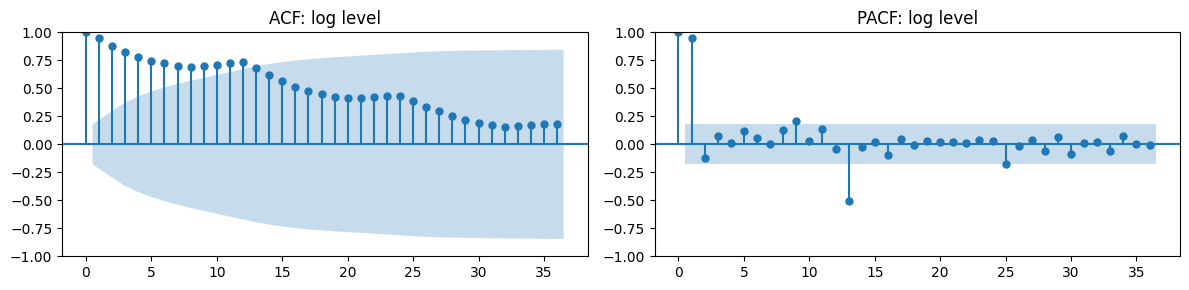

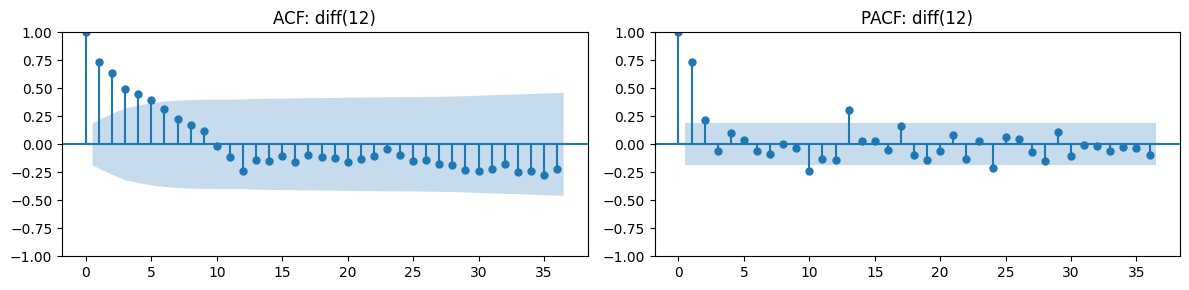

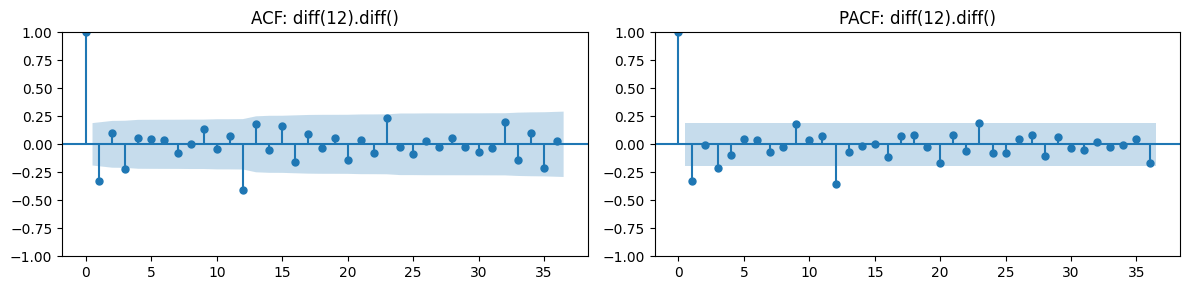

In [64]:
for name, series in [("log level", logair),
                     ("diff(12)", logair.diff(12)),
                     ("diff(12).diff()", logair.diff(12).diff())]:
    s = series.dropna()
    px.line(s.rename_axis("date").reset_index(), x="date", y=s.name, title=name, height=250).show()

    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    plot_acf(s, lags=36, ax=ax[0], title=f"ACF: {name}")
    plot_pacf(s, lags=36, ax=ax[1], title=f"PACF: {name}", method="ywm")
    plt.tight_layout()
    plt.show()

**Reading the bottom row.** After both differences, $d = 1$, $D = 1$, $m = 12$. The ACF and PACF give the orders:

- A spike at **lag 1** in the ACF, cutting off after it, suggests $q = 1$.
- A spike at **lag 12**, with nothing at 24, suggests $Q = 1$.
- Decay in the PACF instead of the ACF would argue for AR terms.

That lands on $\text{ARIMA}(0,1,1)(0,1,1)_{12}$, the "airline model" Box and Jenkins made famous with this dataset.

---
## Part 3. Hand-picked vs. searched

About 12 minutes.

**Tasks.**

1. Fit $(0,1,1)(0,1,1)_{12}$ on `np.log(train)` with `SARIMAX`. Record AICc and test MASE (`np.exp` the forecast back).
2. Run the grid stub below over $p, q, P, Q \in \{0, 1\}$ with $d = D = 1$, and find the AICc minimum.
3. State whether the AICc winner also wins on MASE, and which you would ship.
4. Run Ljung-Box on the winner's residuals and report any structure left.

We forecast on the log scale and back-transform. `np.exp` of a mean forecast is a *median* on the original scale. Week 6 makes that matter.

In [ ]:
def fit_sarima(y_log, order, seasonal_order):
    return SARIMAX(y_log, order=order, seasonal_order=seasonal_order,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)


# Worked example of the scoring you will repeat:
with timed("one SARIMAX fit by hand"):
    res = fit_sarima(np.log(train), (0, 1, 1), (0, 1, 1, 12))
pred = np.exp(res.forecast(h))
print("AICc:", round(res.aicc, 2), " test MASE:", round(mase(test, pred, train, m), 3))


In [ ]:
# YOUR CODE HERE - task 2: the grid. Wrap it in `with timed("16-model grid"):` so we can
# compare its cost against AutoARIMA in Part 5.
# for p in [0, 1]:
#     for q in [0, 1]:
#         for P in [0, 1]:
#             for Q in [0, 1]:
#                 ...


<details>
<summary><b>Solution</b></summary>

```python
rows = []
with timed("16-model grid"):
    for p in [0, 1]:
        for q in [0, 1]:
            for P in [0, 1]:
                for Q in [0, 1]:
                    r = fit_sarima(np.log(train), (p, 1, q), (P, 1, Q, 12))
                    pr = np.exp(r.forecast(h))
                    rows.append({"order": f"({p},1,{q})({P},1,{Q})[12]",
                                 "AICc": r.aicc,
                                 "MASE": mase(test, pr, train, m)})

grid = pd.DataFrame(rows).sort_values("AICc")
print(grid.round(3).to_string(index=False))
print("\nAICc winner:", grid.iloc[0]["order"])
print("MASE winner:", grid.sort_values("MASE").iloc[0]["order"])

best = fit_sarima(np.log(train), (0, 1, 1), (0, 1, 1, 12))
resid = best.resid[13:]
print(acorr_ljungbox(resid, lags=[12, 24], return_df=True))
best.plot_diagnostics(figsize=(11, 7))
plt.show()
```

**What you should find.** The airline model sits at or near the top on both criteria, which is satisfying and slightly rigged: this dataset is where the model came from. The lesson is in the disagreements. AICc is an in-sample complexity penalty, MASE an out-of-sample measurement. Large disagreements usually mean the test window contains something the training window did not.
</details>


---
## Part 3b. AutoARIMA

Your grid fit 16 models. The real space is larger: $p, q \le 5$, $P, Q \le 2$, $d, D$ chosen by test, with and without drift.

`AutoARIMA` implements the Hyndman-Khandakar procedure:

1. Choose $D$ by a seasonal strength test, then $d$ by repeated KPSS tests.
2. Fit four starting models, keep the best AICc.
3. Vary one order at a time by $\pm 1$, accepting any move that improves AICc. Stop at a local minimum.

That is stepwise search, the default. `stepwise=False, approximation=False` fits the whole grid instead. We run both, on both scales, and time all four.


In [65]:
arima_runs = {}
for scale, y, back in [("raw", train, False), ("log", np.log(train), True)]:
    for mode, kw in [("stepwise", {}), ("exhaustive", dict(stepwise=False, approximation=False))]:
        label = f"AutoARIMA {scale}/{mode}"
        sf = StatsForecast(models=[AutoARIMA(season_length=m, **kw)], freq="MS")
        with timed(label):
            sf.fit(df=sf_frame(y))
        pred = sf.predict(h=h)["AutoARIMA"].to_numpy()
        pred = np.exp(pred) if back else pred
        arima_runs[label] = {"chose": picked(sf),
                             "AICc": round(sf.fitted_[0, 0].model_["aicc"], 1),
                             "MASE": round(mase(test, pred, train, m), 3),
                             "seconds": round(TIMINGS[label], 2)}

pd.DataFrame(arima_runs).T


[AutoARIMA raw/stepwise] 0.40s
[AutoARIMA raw/exhaustive] 9.70s
[AutoARIMA log/stepwise] 0.80s
[AutoARIMA log/exhaustive] 8.27s


,chose,AICc,MASE,seconds
AutoARIMA raw/stepwise,"ARIMA(1,1,0)(0,1,0)[12]",803.4,2.4,0.4
AutoARIMA raw/exhaustive,"ARIMA(0,1,3)(0,1,0)[12]",802.7,2.228,9.7
AutoARIMA log/stepwise,"ARIMA(0,1,1)(0,1,1)[12]",-388.7,1.352,0.8
AutoARIMA log/exhaustive,"ARIMA(0,1,1)(0,1,1)[12]",-388.7,1.352,8.27


**Read the four rows.**

1. On the log scale, stepwise and exhaustive return the same model, $(0,1,1)(0,1,1)_{12}$ - the one you picked by hand off the ACF and PACF. Exhaustive took about ten times as long to agree, which is the usual outcome and why stepwise is the default.
2. On the raw scale both pick something worse, and disagree with each other. A search only covers the space you hand it.
3. The ACF/PACF reading from Part 2 is how you check that the search landed somewhere sensible.
4. AICc is again not comparable across the two scales. MASE is.

Automation earns its keep when you are not fitting one series. Part 4 has three more.


---
## Part 4. Three more series, same two selectors

The airline series flatters both families. These three do not.

| Series | Shape | The question it asks |
| --- | --- | --- |
| **Nile** | Annual river flow, 1871-1970, no seasonality, a level shift in 1899 (the Aswan dam) | What should a model do when there is nothing to model? |
| **Sunspots** | Annual counts, a ~11-year *cycle* whose period wanders | Is a cycle the same thing as seasonality? |
| **CO2** | Monthly Mauna Loa, clean trend plus clean seasonality, 500+ observations | What does a long, well-behaved series cost? |

`SeasonalNaive` rides along as the check. A MASE above 1 means the naive forecast beat you.


In [66]:
from statsmodels.datasets import nile, sunspots, co2

_nile = nile.load_pandas().data
nile_s = pd.Series(_nile["volume"].to_numpy(), name="Nile",
                   index=pd.PeriodIndex(_nile["year"].astype(int), freq="Y").to_timestamp())

_sun = sunspots.load_pandas().data
sun_s = pd.Series(_sun["SUNACTIVITY"].to_numpy(), name="Sunspots",
                  index=pd.PeriodIndex(_sun["YEAR"].astype(int), freq="Y").to_timestamp())

co2_s = co2.load_pandas().data["co2"].resample("MS").mean().interpolate().rename("CO2")

cases = [("Nile",     nile_s, 1,  10, "YS"),
         ("Sunspots", sun_s,  1,  20, "YS"),
         ("CO2",      co2_s,  12, 24, "MS")]

rows, forecasts = [], {}
for name, series, season, hz, freq in cases:
    tr, te = series[:-hz], series[-hz:]
    for model in [AutoETS(season_length=season), AutoARIMA(season_length=season),
                  SeasonalNaive(season_length=season)]:
        tag = type(model).__name__
        sf = StatsForecast(models=[model], freq=freq)
        with timed(f"{name}: {tag}"):
            sf.fit(df=sf_frame(tr))
        pred = sf.predict(h=hz)[tag].to_numpy()
        rows.append({"series": name, "model": tag,
                     "chose": picked(sf) if tag != "SeasonalNaive" else "-",
                     "MASE": round(mase(te, pred, tr, season), 3),
                     "seconds": round(TIMINGS[f"{name}: {tag}"], 2)})
        forecasts[(name, tag)] = pd.Series(pred, index=te.index)

pd.DataFrame(rows).set_index(["series", "model"])


[Nile: AutoETS] 0.03s
[Nile: AutoARIMA] 0.63s
[Nile: SeasonalNaive] 0.01s
[Sunspots: AutoETS] 0.02s
[Sunspots: AutoARIMA] 2.09s
[Sunspots: SeasonalNaive] 0.00s
[CO2: AutoETS] 0.60s
[CO2: AutoARIMA] 21.07s
[CO2: SeasonalNaive] 0.00s


chose   MASE  seconds
series   model                                                 
Nile     AutoETS                     ETS(M,N,N)  0.867     0.03
         AutoARIMA                 ARIMA(1,1,1)  0.889     0.63
         SeasonalNaive                        -  0.968     0.01
Sunspots AutoETS                     ETS(A,N,N)  2.895     0.02
         AutoARIMA                 ARIMA(2,1,3)  1.774     2.09
         SeasonalNaive                        -  2.896     0.00
CO2      AutoETS                     ETS(A,A,A)  0.230     0.60
         AutoARIMA      ARIMA(1,1,1)(2,1,1)[12]  0.248    21.07
         SeasonalNaive                        -  1.450     0.00

In [67]:
for name, series, season, hz, freq in cases:
    hist = series[-min(len(series), 8 * hz):]
    panel = pd.concat([hist.rename("actual")] +
                      [forecasts[(name, t)].rename(t) for t in ["AutoETS", "AutoARIMA", "SeasonalNaive"]],
                      axis=1)
    lines(panel, f"{name}: automatic selections", height=320).show()


**What each series shows.**

1. **Nile.** `AutoETS` picks ETS(M,N,N) and `AutoARIMA` picks ARIMA(1,1,1). Both are nearly flat and both barely beat naive. A level plus noise with one break in 1899 has no trend to extrapolate and no season to repeat, so flat is the right answer.
2. **Sunspots.** `AutoETS` loses to the naive forecast; `AutoARIMA` does better with ARIMA(2,1,3) with drift. ETS has no vocabulary for cycles: its season is a fixed-length pattern, and the sunspot cycle wanders between about 9 and 13 years, while AR terms can express a damped pseudo-cycle. Both are poor in absolute terms.
3. **CO2.** Both do well, but `AutoARIMA` takes twenty to thirty times longer than `AutoETS` for a slightly worse forecast. Part 5 is about when that matters.


---
## Part 5. What does it cost?

"ARIMA is a good tool" and "ARIMA is affordable" are different claims. Every fit today was timed, so we can read the bill.

Two questions:

1. Where did the time go?
2. What happens to that number as the series gets longer, the season gets wider, and the panel gets bigger?


In [ ]:
cost = (pd.Series(TIMINGS, name="seconds").sort_values(ascending=False)
          .to_frame().round(2))
cost["share of notebook"] = (100 * cost["seconds"] / cost["seconds"].sum()).round(1).astype(str) + "%"
cost


In [ ]:
# What actually drives the cost? Two knobs: series length, and seasonal period.
# Same seed per configuration, so every comparison is the same data.

def synth(n, period, seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    y = 100 + 0.1 * t + 8 * np.sin(2 * np.pi * t / max(period, 2)) + rng.normal(scale=2, size=n)
    return pd.Series(y, index=pd.date_range("2000-01-01", periods=n, freq="MS"))


def time_fit(model, y, h=12):
    sf = StatsForecast(models=[model], freq="MS")
    t0 = time.perf_counter()
    sf.forecast(df=sf_frame(y), h=h)
    return time.perf_counter() - t0


print("AutoARIMA vs. series length (m = 12)")
length_cost = {}
for n in [120, 240, 480]:
    length_cost[n] = time_fit(AutoARIMA(season_length=12), synth(n, 12))
    print(f"   n = {n:4d} : {length_cost[n]:6.2f}s")

print("\nBoth families vs. seasonal period (n = 480)")
season_cost = {}
for period in [1, 6, 12]:
    y = synth(480, period)
    season_cost[period] = {"AutoARIMA": time_fit(AutoARIMA(season_length=period), y),
                           "AutoETS":   time_fit(AutoETS(season_length=period), y)}
    print(f"   m = {period:2d} : AutoARIMA {season_cost[period]['AutoARIMA']:6.2f}s"
          f"   AutoETS {season_cost[period]['AutoETS']:5.2f}s")

# m = 24 is left out on purpose: on the hardware this was written on it takes about
# 160 seconds for AutoARIMA - twenty times the m = 12 cost - and m = 52 did not finish
# in ten minutes. Uncomment to watch it happen.
# print(time_fit(AutoARIMA(season_length=24), synth(480, 24)))


In [ ]:
by_length = (pd.Series(length_cost, name="seconds").rename_axis("knob").reset_index()
               .assign(sweep="seconds vs. series length (AutoARIMA, m=12)", model="AutoARIMA"))
by_season = (pd.DataFrame(season_cost).T.rename_axis("knob").reset_index()
               .melt(id_vars="knob", var_name="model", value_name="seconds")
               .assign(sweep="seconds vs. seasonal period (n=480)"))

fig = px.line(pd.concat([by_length, by_season]), x="knob", y="seconds", color="model",
              facet_col="sweep", markers=True, height=360,
              title="What makes automatic selection slow")
fig.update_xaxes(matches=None, title="")
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=", 1)[-1]))
fig.show()


In [ ]:
# The number that actually decides your architecture: seconds per series, times series.
per_series = {"AutoETS (CO2, m=12)": TIMINGS["CO2: AutoETS"],
              "AutoARIMA (CO2, m=12)": TIMINGS["CO2: AutoARIMA"]}

budget = pd.DataFrame({
    name: {"one series (sec)": sec,
           "1,000 series, 1 core (min)": sec * 1000 / 60,
           "1,000 series, 8 cores (min)": sec * 1000 / 60 / 8}
    for name, sec in per_series.items()
}).T
budget.round(2)


**Reading the bill.**

1. The seasonal period drives the cost, not the length of the series. Quadrupling the observations roughly quadruples the time. Widening $m$ does more, because every candidate gains seasonal terms and a seasonal difference and each fit's state space grows with $m$. On this hardware, `AutoARIMA` on 480 points takes about 0.7s at $m = 1$, about 7s at $m = 12$, and about 160s at $m = 24$; at $m = 52$ it did not finish in ten minutes.
2. `AutoETS` stays under a second at every $m$ we tried. Its seasonal component is one state vector of length $m$, not a search over seasonal AR and MA orders.
3. That is why Week 2 spent its time on MSTL, and why hourly data with a weekly cycle ($m = 168$) does not go near seasonal ARIMA. You decompose the seasonality out, or encode it as features for a regression, which is Week 4.
4. Exhaustive search costs about ten times stepwise and usually agrees with it. Use it to audit one series, not as a default on a panel.
5. Do the arithmetic before designing the pipeline. `StatsForecast(..., n_jobs=-1)` parallelizes across series; the next lever is not fitting per-series models at all, which is the Week 5 argument.

**Discussion.** 50,000 SKU-store series, daily, with weekly and annual seasonality, and a four-hour nightly window. Using today's numbers, what fits? What do you give up first - the search, the seasonality, or the per-series model?


---
## Wrap-up

1. **ETS and ARIMA are different languages for the same thing.** ETS thinks in components, ARIMA in autocorrelation. Where they differ it matters: ETS cannot express a cycle.
2. **Differencing is ARIMA's price of admission.** Check with two tests that fail in opposite directions.
3. **AICc ranks in-sample, MASE measures out-of-sample.** Report both and investigate disagreements. AICc cannot compare models fitted to different data, so it cannot choose your transformation.
4. **Automatic selection searches the space you give it.** It replaces your grid, not your judgment: the transform, the seasonal period, the horizon, and the residual checks are still yours.
5. **Know the runtime, not just the model.** Seconds per series times panel size is an architecture decision, and the seasonal period is the term that blows it up.
6. **Combine rather than select** when several models are close.

Next week: the same problem, handed to machine learning.
